## UML Demo

This notebook demonstrates the `PhysComp.uml` module, which decomposes and reconstructs data

### Functions covered:
- `uml.decomp_data` — decompose and reconstruct data
- `uml.get_components` — find a set of single components of the decomposition
- `uml.scree_plot` — find and optionally plot the scree plot
- `uml.find_elbow` — find the elbow from the scree plot

#### Needed Imports

In [2]:
## Needed imports for module
import hyperspy.api as hs
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional

## Simulation module for example data
import PhysComp.sim as sim

## Import actual uml module
import PhysComp.uml as uml

## Simulating Data

In [3]:
simulated_dataset = sim.sim_dataset(30,30,360,100,100, filesave= True,save_path="Test.npy", seed=100) # Simulating data, see Sim notebook

## Functions

### Decomp_data

Docstring:

"""
   
    Decomposes file given by path, using UML into given number of components for given algorithm

    Parameters:
    - path : str : path of file for decomposition
    - algo : str : desired algorithm for decomposition (e.g. 'SVD', 'NMF')
    - plot : bool : whether to display scree plot (default False)
    - components : int or None : number of components for reconstruction.
                    If None, automatically uses scree plot to determine optimal number of comps.

    Returns:
    - decomposed_data : np.ndarray : reconstructed data with given (or calculated) number of components
    - raw_data_end : np.ndarray : raw data array
"""

This function takes a dataset given by a filepath and decomposes it into components using the given algorithm, then reconstructs it using a given number of components. If no given number of components, then the function will determine ideal components through Scree Plot elbow.

In [4]:
path = "Test.npy" #Filepath for dataset to decompose
algorithm = "SVD" # Chosen algorithm for decomposition
comps = 3 # Chosen number of components, if left blank will be calculated by scree plot
plotting = False # If true plots scree plot

sd = uml.decomp_data(path,algorithm, components=comps, plot=plotting)

Decomposition info:
  normalize_poissonian_noise=False
  algorithm=SVD
  output_dimension=None
  centre=None
Scree Plot: calculated 4 relevant components


The variable sd is an array with form [decomposed_data, raw_data]

### get_components

Docstring:

 """
    
    Extract and optionally plot individual decomposition components.

    Parameters:
    - decomposed_obj : hyperspy signal : decomposed hyperspy object
    - components : list of int : component indices to extract (can use np.arange(X) to produce first X comps)
    - degree : int : degree for slice of 2d image plot (default 0, shows degree 0 slice)
    - pixel : list of int : [row, col] pixel coordinates for single pixel plot (default [0,0], shows first pixel)
    - size : list of int : figure size [width, height] (default [10, 10])
    - plot : bool : whether to plot components (default False)

    Returns:
    - components_array : list of np.ndarray : data arrays for each component
"""

This function calculates a given component or set of components for a previously decomposed object. If plotting is enabled it will visualise a chosen slice and pixel.

First have to decompose an object to feed into the function:

In [5]:
raw_data = hs.load("Test.npy")
data_hs_func = hs.signals.Signal1D(raw_data.data)
data_hs_func.decomposition(algorithm="SVD")

Decomposition info:
  normalize_poissonian_noise=False
  algorithm=SVD
  output_dimension=None
  centre=None


Then use the function to extract the 1st,10th,100th components

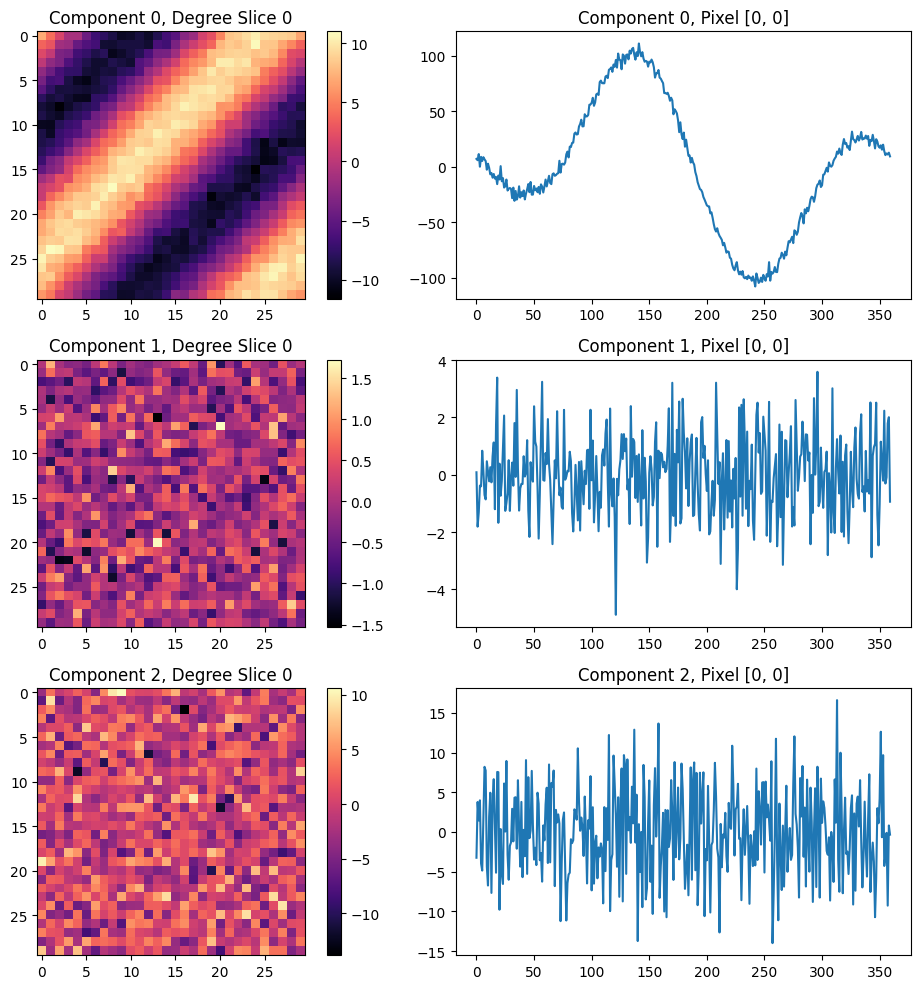

In [6]:
decomposed_obj = data_hs_func # Hyperspy decomposed object
comps = [1,10,100] # Chosen components, for this example we are showing component 1,10,100
plotting = True # If false just stores arrays no visualisation

components = uml.get_components(decomposed_obj,comps, plot = plotting)

### Scree_plot

Docstring:

"""

    Calculate and optionally plot a scree plot for decomposition results.

    Parameters:
    - decomposed_obj : hyperspy signal : decomposed hyperspy object
    - plot : bool : whether to display the scree plot (default False)

    Returns:
    - num_relevant_comps : int : number of relevant components found at elbow
    - relevant_comps : np.ndarray : array of relevant component indices
    - EVR : np.ndarray : explained variance ratio for all components
    - component_num : np.ndarray : array of component indices
"""

For a given decomposed object, generate a scree plot and calculate the elbow, thus identifying the relevant components.

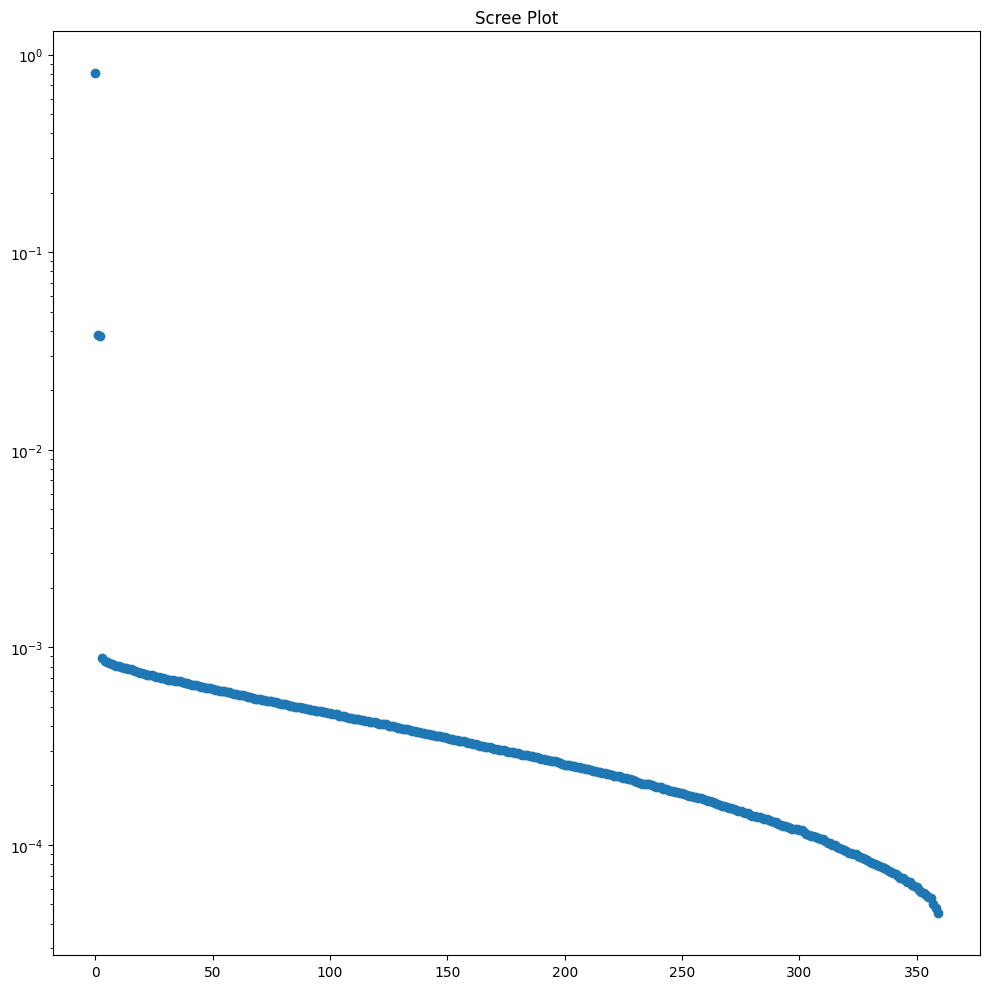

Scree Plot: calculated 4 relevant components


In [30]:
scree_plot = uml.scree_plot(data_hs_func,plot=True)

### Find_elbow

Docstring:

"""
    
    Find elbow point in scree plot data using maximum distance from line method.

    Parameters:
    - variance : array-like : variance explained values from decomposition (can be founs via scree_plot)

    Returns:
    - relevant_components : np.ndarray : components to keep (up to and including elbow, use len() to find number of components)
"""

Finds elbow in scree plot for given varience values

In [29]:
variance = data_hs_func.get_explained_variance_ratio().data # Getting varience values
relavent_comps = uml.find_elbow(variance) # Using Function
print(relavent_comps) # Displaying output

[1. 2. 3. 4.]
